In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv(r"D:\Downloads\FinancialAnalysis.csv")

In [3]:
df.head()

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,Market Cap,EBITDA,Price/Book,Unnamed: 10
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,1.387210e+11,9.048000e+09,11.34,NaN
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,1.078342e+10,6.010000e+08,6.35,NaN
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,1.021210e+11,5.744000e+09,3.19,NaN
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,1.813860e+11,1.031000e+10,26.14,NaN
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,9.876586e+10,5.643228e+09,10.62,NaN


In [4]:
df["Unnamed: 10"].isnull().sum()

np.int64(505)

In [5]:
df.shape

(505, 11)

Removing empty columns

In [6]:
df= df.dropna(axis=1, how="all")

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          505 non-null    str    
 1   Name            505 non-null    str    
 2   Sector          505 non-null    str    
 3   Price           505 non-null    float64
 4   Price/Earnings  503 non-null    float64
 5   Dividend Yield  505 non-null    float64
 6   Earnings/Share  505 non-null    float64
 7   Market Cap      505 non-null    float64
 8   EBITDA          505 non-null    float64
 9   Price/Book      497 non-null    float64
dtypes: float64(7), str(3)
memory usage: 39.6 KB


Missing Value Analysis


In [8]:
df.isnull().sum()

Symbol            0
Name              0
Sector            0
Price             0
Price/Earnings    2
Dividend Yield    0
Earnings/Share    0
Market Cap        0
EBITDA            0
Price/Book        8
dtype: int64

In [9]:
df= df.dropna()

In [10]:
df.isnull().sum()

Symbol            0
Name              0
Sector            0
Price             0
Price/Earnings    0
Dividend Yield    0
Earnings/Share    0
Market Cap        0
EBITDA            0
Price/Book        0
dtype: int64

The dataset contained a small number of missing values in Price/Earnings and Price/Book columns. Since the missing records represented a very small portion of the dataset, they were removed to ensure accurate valuation and ratio analysis.

In [11]:
df.shape

(495, 10)

Duplicate Record Analysis

In [12]:
df.duplicated().sum()

np.int64(0)

The dataset was checked for duplicate records to ensure that each company was represented only once. Duplicate observations, if present, were removed to avoid biased calculations and inaccurate financial insights.

overall statistical summary of the financial variables

In [13]:
df.describe()

,Price,Price/Earnings,Dividend Yield,Earnings/Share,Market Cap,EBITDA,Price/Book
count,495.000000,495.000000,495.000000,495.000000,4.950000e+02,4.950000e+02,495.000000
mean,104.106505,24.654303,1.901477,3.815192,4.937665e+10,3.576406e+09,14.498687
std,135.372594,40.767081,1.541039,5.529133,9.069161e+10,6.880742e+09,89.838923
min,2.820000,-251.530000,0.000000,-24.620000,2.626102e+09,-5.067000e+09,0.510000
25%,46.355000,15.350000,0.795585,1.525000,1.274957e+10,7.708980e+08,2.020000
50%,73.920000,19.450000,1.790190,2.890000,2.143378e+10,1.613000e+09,3.400000
75%,116.735000,25.770000,2.797169,5.120000,4.499315e+10,3.657500e+09,6.130000
max,1806.060000,520.150000,12.661196,44.090000,8.095080e+11,7.938600e+10,1403.380000


Key Findings
The average stock price across the companies is $104.11,    while  the  highest  stock price is $1806.06, indicating significant variation in stock valuations.
The average Price-to-Earnings (PE) ratio is 24.65, suggesting that investors are willing to pay approximately 25 times earnings for the average company.
The average Dividend Yield is 1.90%, showing that many companies provide income to shareholders, although some do not pay dividends.
The average Market Capitalization is approximately $49.38 billion, while  the largest company has a market capitalization exceeding $809 billion, highlighting the presence of very large firms in the index.
The average Price-to-Book ratio is 14.50, but the extremely high maximum value indicates the presence of potential outliers.

OBSERVATIONS FROM DESCRIPTIVE ANALYSIS
Observation 1: Presence of Loss-Making Companies

The dataset contains companies with negative Earnings Per Share (EPS) and negative Price-to-Earnings (PE) ratios. This indicates that some companies are currently reporting losses rather than profits.

Observation 2: Negative EBITDA Values

A few companies have negative EBITDA values, suggesting that their operating expenses exceed operating earnings. These firms may be experiencing operational challenges or are in a growth phase.

Observation 3: Significant Variation in Company Size

Market capitalization ranges from approximately $2.6 billion to over $809 billion, indicating that the dataset includes companies of vastly different sizes.

Observation 4: Presence of Outliers

The large difference between the average and maximum values of metrics such as Price-to-Book ratio suggests the presence of outliers. These extreme values may influence overall averages and should be considered during analysis.

Which sectors contain the highest number of companies in the dataset?

In [14]:
df["Sector"].value_counts()

Sector
Consumer Discretionary        82
Information Technology        70
Financials                    68
Industrials                   64
Health Care                   59
Real Estate                   33
Consumer Staples              33
Energy                        30
Utilities                     28
Materials                     25
Telecommunication Services     3
Name: count, dtype: int64

The dataset is diversified across multiple sectors, with Consumer Discretionary (82 companies) being the most represented sector, followed by Information Technology (70 companies) and Financials (68 companies).

Healthcare and Industrials also have substantial representation, while Telecommunication Services contains only 3 companies, making it the least represented sector in the dataset.

The distribution suggests that consumer-focused, technology, and financial businesses make up a significant portion of the S&P 500 universe.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Sector',
    order=df['Sector'].value_counts().index
)

plt.title('Number of Companies by Sector')
plt.xlabel('Number of Companies')
plt.ylabel('Sector')

plt.show()

The visualization confirms that Consumer Discretionary, Information Technology, and Financials are the most represented sectors. Telecommunication Services has minimal representation. The distribution is uneven across sectors, highlighting differences in industry participation within the S&P 500 index.

Sector-wise Market Capitalization

Which sectors contribute the highest total market capitalization?

In [16]:
sector_marketcap = (
    df.groupby('Sector')['Market Cap']
      .sum()
      .sort_values(ascending=False)
)

sector_marketcap

Sector
Information Technology        6.727122e+12
Financials                    3.442650e+12
Health Care                   3.197584e+12
Consumer Discretionary        3.193496e+12
Industrials                   2.282662e+12
Consumer Staples              1.925663e+12
Energy                        1.289972e+12
Materials                     6.922999e+11
Real Estate                   6.253157e+11
Utilities                     6.116326e+11
Telecommunication Services    4.530422e+11
Name: Market Cap, dtype: float64

The Information Technology sector has the highest total market capitalization at approximately $6.73 trillion, making it the most valuable sector in the dataset.

Financials and Health Care follow with total market capitalizations of approximately $3.44 trillion and $3.20 trillion, respectively.

Telecommunication Services has the lowest total market capitalization among all sectors, contributing approximately $0.45 trillion.

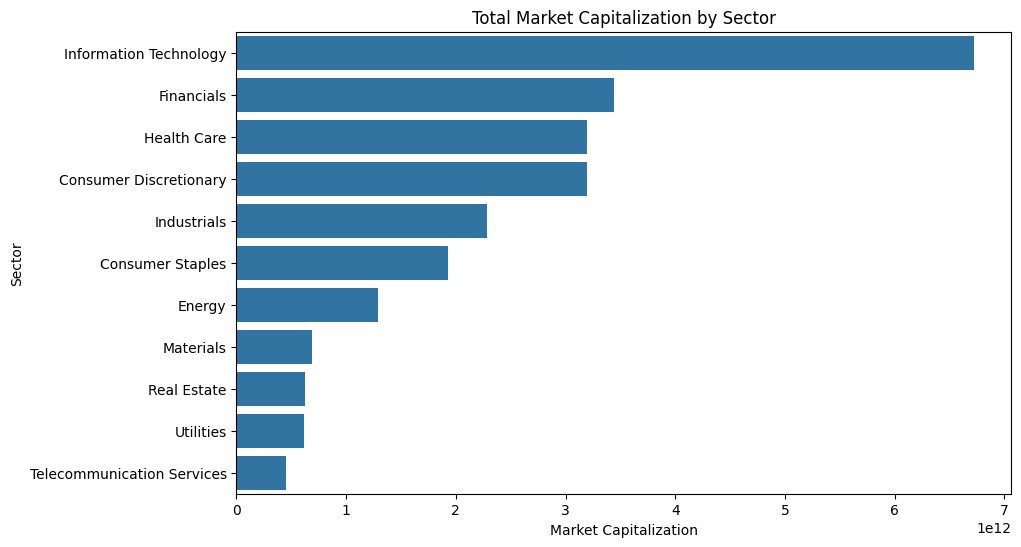

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=sector_marketcap.values,
    y=sector_marketcap.index
)

plt.title('Total Market Capitalization by Sector')
plt.xlabel('Market Capitalization')
plt.ylabel('Sector')

plt.show()

**Which companies have the highest Price-to-Earnings (PE) ratios?

In [19]:
top_pe = (
    df[['Name', 'Sector', 'Price/Earnings']]
      .sort_values('Price/Earnings', ascending=False)
      .head(10)
)

top_pe

,Name,Sector,Price/Earnings
403,Salesforce.com,Information Technology,520.15
64,"Baker Hughes, a GE Company",Energy,305.56
30,Amazon.com Inc,Consumer Discretionary,296.16
475,Vertex Pharmaceuticals Inc,Health Care,252.67
171,EOG Resources,Energy,246.44
326,Netflix Inc.,Information Technology,200.08
404,SBA Communications,Real Estate,199.81
9,Advanced Micro Devices Inc,Information Technology,187.00
103,Charter Communications,Consumer Discretionary,162.92
366,Pioneer Natural Resources,Energy,118.29


The highest PE ratio in the dataset belongs to Salesforce.com (520.15), followed by Baker Hughes (305.56) and Amazon (296.16).

Several Technology companies, including Salesforce, Netflix, and AMD, appear among the highest PE ratio companies, indicating strong investor expectations regarding future growth.

**Which companies have the largest market capitalization?

In [20]:
top_marketcap = (
    df[['Name', 'Sector', 'Market Cap']]
      .sort_values('Market Cap', ascending=False)
      .head(10)
)

top_marketcap

,Name,Sector,Market Cap
51,Apple Inc.,Information Technology,8.095080e+11
27,Alphabet Inc Class A,Information Technology,7.338240e+11
28,Alphabet Inc Class C,Information Technology,7.285360e+11
311,Microsoft Corp.,Information Technology,6.899780e+11
30,Amazon.com Inc,Consumer Discretionary,6.858730e+11
187,"Facebook, Inc.",Information Technology,5.234230e+11
263,JPMorgan Chase & Co.,Financials,3.866140e+11
261,Johnson & Johnson,Health Care,3.530620e+11
185,Exxon Mobil Corp.,Energy,3.261490e+11
66,Bank of America Corp,Financials,3.214780e+11


The largest company in the dataset is Apple Inc., with a market capitalization of approximately $809.5 billion.

The top positions are dominated by major technology companies, including Apple, Alphabet, Microsoft, Facebook, and Amazon.

Among non-technology companies, JPMorgan Chase, Johnson & Johnson, Exxon Mobil, and Bank of America rank among the most valuable companies.

In [21]:
df = df.reset_index(drop=True)

TOP COMPANIES BY EBITDA

 Which companies generate the highest EBITDA?

In [22]:
top_ebitda = (
    df[['Name', 'Sector', 'EBITDA']]
      .sort_values('EBITDA', ascending=False)
      .head(10)
)

top_ebitda

,Name,Sector,EBITDA
51,Apple Inc.,Information Technology,7.938600e+10
57,AT&T Inc,Telecommunication Services,4.965300e+10
464,Verizon Communications,Telecommunication Services,4.574500e+10
307,Microsoft Corp.,Information Technology,4.107900e+10
184,Exxon Mobil Corp.,Energy,3.905200e+10
27,Alphabet Inc Class A,Information Technology,3.421700e+10
28,Alphabet Inc Class C,Information Technology,3.271400e+10
470,Wal-Mart Stores,Consumer Staples,3.072100e+10
104,Chevron Corp.,Energy,2.887700e+10
121,Comcast Corp.,Consumer Discretionary,2.867500e+10


Apple Inc. reports the highest EBITDA in the dataset at approximately $79.4 billion, followed by AT&T and Verizon.

The top EBITDA-generating companies belong primarily to the Information Technology, Telecommunication Services, and Energy sectors, indicating strong operational profitability within these industries.

*Correlation Analysis


 How are the financial metrics related to each other?

In [23]:
corr = df.corr(numeric_only=True)

corr

,Price,Price/Earnings,Dividend Yield,Earnings/Share,Market Cap,EBITDA,Price/Book
Price,1.000000,0.199171,-0.245344,0.609033,0.407754,0.180636,0.023509
Price/Earnings,0.199171,1.000000,-0.200884,0.008879,0.132557,0.000812,0.000366
Dividend Yield,-0.245344,-0.200884,1.000000,-0.088261,-0.026873,0.122394,0.089067
Earnings/Share,0.609033,0.008879,-0.088261,1.000000,0.194429,0.177936,0.031638
Market Cap,0.407754,0.132557,-0.026873,0.194429,1.000000,0.770722,0.034220
EBITDA,0.180636,0.000812,0.122394,0.177936,0.770722,1.000000,0.035304
Price/Book,0.023509,0.000366,0.089067,0.031638,0.034220,0.035304,1.000000


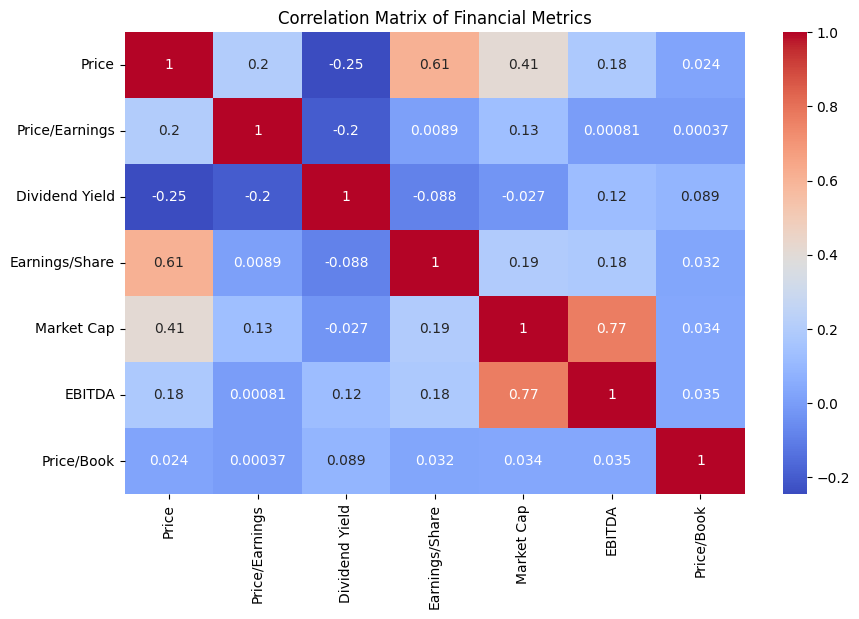

In [24]:


plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Financial Metrics')

plt.show()

Key Findings

Market Capitalization and EBITDA show a strong positive correlation (0.77).

This indicates that larger companies tend to generate higher operating profits.

Price and Earnings Per Share (EPS) exhibit a moderately strong positive correlation (0.61).

Companies with higher earnings generally have higher stock prices.

Price and Market Capitalization show a moderate positive relationship (0.41).

Higher-priced stocks are often associated with larger companies, although the relationship is not very strong.

Dividend Yield has a weak negative correlation with Price (-0.25).

Higher-priced stocks tend to offer slightly lower dividend yields.

Price-to-Book ratio shows very weak correlations with other financial metrics.

This suggests that Price-to-Book captures a different aspect of company valuation.

In [25]:
df.to_csv('financial_analysis_cleaned.csv', index=False)